#  PHASE 5 — FEATURE ENGINEERING: NEW FEATURES

What Is Feature Engineering?
Definition: Creating NEW features from existing data that better capture the underlying patterns relevant to your prediction task.

- Raw Features
Spread across many columns
Hard to explain individual features
Individual signals may be weak
Generic data

- Engineered Features
Condensed into meaningful metrics
Intuitive (e.g., "HouseAge" vs "YearBuilt")
Combined signals are stronger
Encodes real-world understanding

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset from Phase 4
df = pd.read_csv("../data/train_processed_phase4.csv")
print(f"Dataset loaded successfully. Shape: {df.shape}")

Dataset loaded successfully. Shape: (1456, 79)


##  AGGREGATION FEATURES
Concept: Why Aggregate?
Problem: Related features are split across multiple columns. A house's total living space is spread across TotalBsmtSF, 1stFlrSF, and 2ndFlrSF.

Solution: Combine them into a single metric that represents the complete picture.

Why It Helps Models:

Reduces multicollinearity (three correlated features become one)
Creates more intuitive predictors
Captures the "total space" concept buyers actually care about

## Feature 1: Total Effective Surface Area (`TotalEffectiveSF`)

**Description:**
`TotalEffectiveSF` calculates the total built footprint of a property by adding up every constructed surface: the main living floors (`GrLivArea`), basement (`TotalBsmtSF`), decks (`WoodDeckSF`), and all porches (`OpenPorchSF`, `EnclosedPorch`, `3SsnPorch`, `ScreenPorch`).

**Why this helps the model:**
Standard real estate metrics like `GrLivArea` only look at above-ground living space, completely ignoring basements, decks, and porches. 

While `LotArea` measures the size of the land (the plot), `TotalEffectiveSF` measures the total size of the building built on top of that land. Combining all 7 structure columns into one grand total hands the model the full physical size of the house immediately, without making it struggle to calculate the total across separate columns.

In [10]:
# 1. Define component surface area features
surface_cols = [
    "TotalBsmtSF",
    "GrLivArea",
    "WoodDeckSF",
    "OpenPorchSF",
    "EnclosedPorch",
    "3SsnPorch",
    "ScreenPorch",
]

# 2. Create TotalEffectiveSF feature (filling missing values with 0 if present)
df["TotalEffectiveSF"] = df[surface_cols].fillna(0).sum(axis=1)

# 3. Validation: Correlation check against SalePrice
corr_grliv = df["GrLivArea"].corr(df["SalePrice"])
corr_totalsf = df["TotalEffectiveSF"].corr(df["SalePrice"])

print(f"Correlation (GrLivArea vs SalePrice):        {corr_grliv:.4f}")
print(f"Correlation (TotalEffectiveSF vs SalePrice): {corr_totalsf:.4f}")

#

Correlation (GrLivArea vs SalePrice):        0.7205
Correlation (TotalEffectiveSF vs SalePrice): 0.8199


## Feature 2: Neighborhood Scale Relative Index (`NeighborhoodRelativeScale`)

**Description:**
`NeighborhoodRelativeScale` measures how big a home's living area (`GrLivArea`) is compared to the typical (median) home size in its specific `Neighborhood`.

**Formula:**
$$\text{NeighborhoodRelativeScale} = \frac{\text{GrLivArea}}{\text{Median GrLivArea of Neighborhood}}$$

**Real-World Example:**
* **A 2,000 sq ft house in "OldTown"** (where neighbors average 1,000 sq ft) gets a score of **2.0**. It is twice as big as its surroundings ("over-developed").
* **A 2,000 sq ft house in "RichSuburbs"** (where neighbors average 4,000 sq ft) gets a score of **0.5**. It is half the size of its surroundings ("under-developed").

**Why this helps the model:**
Real estate value depends heavily on local context. A massive house surrounded by small homes often suffers from diminishing returns on price per square foot. This feature converts the text category `Neighborhood` and `GrLivArea` into a single, easy-to-understand ratio that directly tells the model whether a house is oversized, normal, or undersized for its block.

In [11]:
# # 1. Calculate the median living area (GrLivArea) for each neighborhood
# neighborhood_medians = df.groupby("Neighborhood")["GrLivArea"].transform(
#     "median"
# )

# # 2. Create the relative scale ratio feature
# df["NeighborhoodRelativeScale"] = df["GrLivArea"] / neighborhood_medians

# # 3. Validation: Compare correlations with SalePrice
# corr_grliv = df["GrLivArea"].corr(df["SalePrice"])
# corr_scale = df["NeighborhoodRelativeScale"].corr(df["SalePrice"])

# print(f"Correlation (Raw GrLivArea vs Price):         {corr_grliv:.4f}")
# print(f"Correlation (Neighborhood Relative Scale vs Price): {corr_scale:.4f}")


# AGE-BASED FEATURES
- Concept: Why Age Features?
Problem: YearBuilt is an absolute year (e.g., 1960, 1995, 2010). But what matters for price is not the year itself—it's how OLD the house is.

Key Insight: A house built in 1960 was:

10 years old if sold in 1970
50 years old if sold in 2010
65 years old if sold in 2025
Why Age Matters:

Newer houses typically require less maintenance
Older houses may have vintage charm (positive) or outdated systems (negative)
Age is more intuitive than construction year for interpretation


## ! i am dropping these column because year are treated as continous numeric col in phase 7 while they are year

In [12]:
# # Calculate age metrics relative to the year the house was sold
df["HouseAge"] = df["YrSold"] - df["YearBuilt"]
df["RemodAge"] = df["YrSold"] - df["YearRemodAdd"]
df["IsRemodeled"] = (df["YearBuilt"] != df["YearRemodAdd"]).astype(int)

# Justification: Buyers heavily discount older homes unless they have been recently renovated, making age and remodeling history critical non-linear factors.
# Quick Check:
print("Age Correlations:\n", df[["HouseAge", "IsRemodeled", "SalePrice"]].corr())


Age Correlations:
              HouseAge  IsRemodeled  SalePrice
HouseAge     1.000000     0.416464  -0.535507
IsRemodeled  0.416464     1.000000  -0.023562
SalePrice   -0.535507    -0.023562   1.000000


## 3. Binary / Flag Features

Zero-values in area or count columns can sometimes distort continuous models. By converting structural amenities like pools, garages, fireplaces, and second floors into clean binary presence flags, we isolate the baseline premium value of having these features versus not having them at all.
- Create explicit binary flags that clearly signal presence/absence.

Why It Helps:

Makes the "has feature" signal explicit
Easier for model to learn price premiums
More interpretable than zero-inflated continuous values

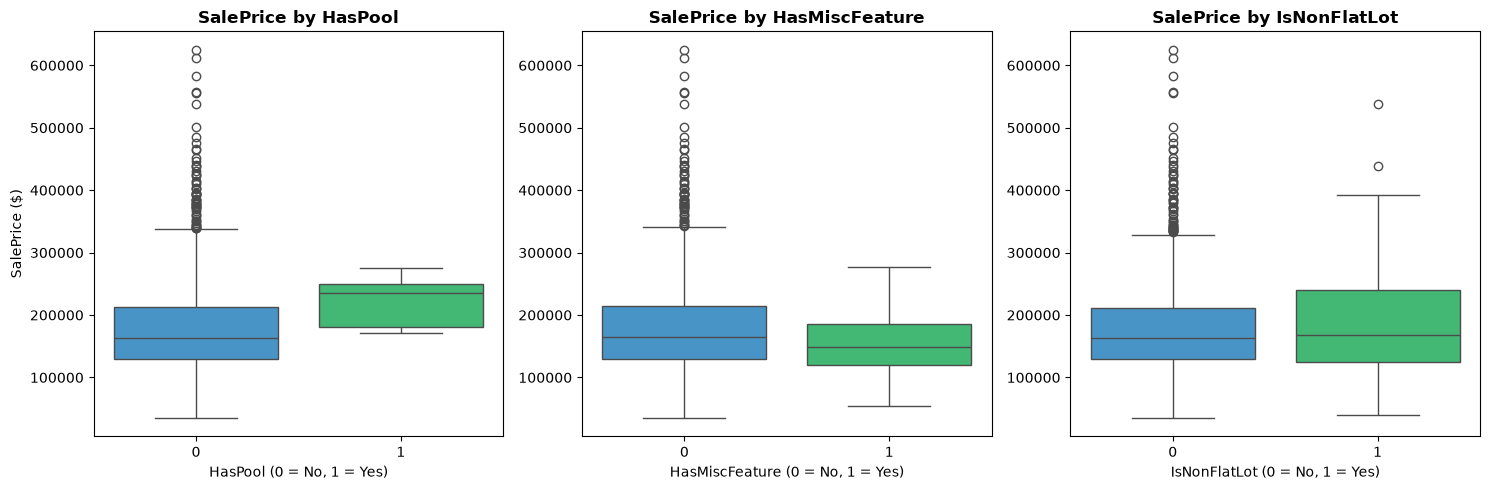

In [13]:
# # Create binary presence indicators
df["HasPool"] = (df["PoolArea"] > 0).astype(int)



# 2. Flag presence of miscellaneous assets (sheds, tennis courts, etc.)
df["HasMiscFeature"] = (df["MiscVal"].fillna(0) > 0).astype(int)

# 3. Flag non-flat land contours (HLS, Bnk, Low vs Lvl)
df["IsNonFlatLot"] = (~df["LandContour"].isin(["Lvl"])).astype(int)

features = ["HasPool", "HasMiscFeature", "IsNonFlatLot"]

plt.figure(figsize=(15, 5))

for i, col in enumerate(features, 1):
    plt.subplot(1, 3, i)
    
    # Fix: Set hue=col and legend=False to resolve warning
    sns.boxplot(
        x=col, 
        y="SalePrice", 
        data=df, 
        hue=col, 
        palette=["#3498db", "#2ecc71"], 
        legend=False
    )
    
    plt.title(f"SalePrice by {col}", fontsize=12, fontweight="bold")
    plt.xlabel(f"{col} (0 = No, 1 = Yes)", fontsize=10)
    plt.ylabel("SalePrice ($)" if i == 1 else "", fontsize=10)
    plt.ticklabel_format(style="plain", axis="y")

plt.tight_layout()
plt.show()

In [14]:
#Droping no useful column 

df.drop(columns=['YrSold', 'YearBuilt','YearRemodAdd'], inplace=True, errors='ignore')


## 4. Counting / Combining Feature: Total Bathrooms

: Why Combine Counts?
Problem: Bathroom count is split across four columns: FullBath, HalfBath, BsmtFullBath, BsmtHalfBath. But a house with 2 full baths isn't necessarily better than a house with 1 full + 2 half baths.

Solution: Create a weighted total that reflects the real value of each bathroom type.

Weighting Logic:

Full bathroom = 1.0 (sink, toilet, shower/tub)
Half bathroom = 0.5 (sink, toilet only)

Weighted Aggregation (What this code does): A half-bathroom (just a toilet and a sink) is not worth the same amount of money to a home buyer as a full bathroom (toilet, sink, and a shower/tub). By multiplying half-baths by 0.5, you are telling the computer: "A half-bath counts as half of a full bath."

### why not aggregation feature:
-- you just add them up normally (FullBath + HalfBath + BsmtFullBath + BsmtHalfBath), you are treating every bathroom equally. If a house has 1 full bath and 1 half bath, a normal sum would treat it as 2 total bathrooms.
   House A:  HalfBath +  HalfBath +  HalfBath  = 3 price more --->wrong
   House B: 2fullbath =2 low price ----wrong

-count/combining:

    House A:  HalfBath(0.5) +  HalfBath(0.5) +  HalfBath(0.5)  = 1.5 price low 
    House B: 2fullbath =2  high price
   


In [15]:

# df['TotalBathrooms'] = (
#     df['FullBath'] + 
#     0.5 * df['HalfBath'] + 
#     df['BsmtFullBath'] + 
#     0.5 * df['BsmtHalfBath']
# )

# # Validation: Correlation and scatter plot
# # total_bath_corr = df['TotalBathrooms'].corr(df['SalePrice_Log'])
# print(f"TotalBathrooms Correlation with SalePrice: r = {total_bath_corr:.3f}")

# print(f"\nIndividual Bathroom Feature Correlations:")
# print(f"  FullBath:      r = {df['FullBath'].corr(df['SalePrice_Log']):.3f}")
# print(f"  HalfBath:      r = {df['HalfBath'].corr(df['SalePrice_Log']):.3f}")
# print(f"  BsmtFullBath:  r = {df['BsmtFullBath'].corr(df['SalePrice_Log']):.3f}")
# print(f"  BsmtHalfBath:  r = {df['BsmtHalfBath'].corr(df['SalePrice_Log']):.3f}")
# print("BsmtHalfBath r is close to 0 so is mean very little impact with price")


## 11. Save Phase 5 Dataset

Now that all new features have been engineered, validated, and added to the dataframe, we save the enhanced dataset so it is ready for Phase 6 modeling.

In [16]:

output_path = '../data/train_processed_phase5.csv'
df.to_csv(output_path, index=False)
print("Phase 5 complete! Saved successfully as 'train_processed_phase5.csv'. Total columns:", df.shape[1])

Phase 5 complete! Saved successfully as 'train_processed_phase5.csv'. Total columns: 83
